## Yellow-legged hornet model

11 - Patch construction

**12 - Grid Search**

13 - PSO

14 - Simulation

15 - Map

**Spatial Division 1**

 Region 1: France

 Region 2: others

Spatial Division 2

 Region 1: France _+ Portugal

 Region 2: others


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from scipy.optimize import minimize
import os
import zipfile
import warnings

In [ ]:
patch_df = pd.read_csv("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_patch_attributes_V6.csv")

In [ ]:
# patch_df = pd.read_csv("outputs/hornet_patch_attributes_V6.csv")

In [ ]:
patch_df.head()

,patch_id,cell_area,land_area,land_prop,A_i,occyear1,occyear2,region
0,0,400000000.0,1.796594e+08,0.449148,179.659369,0,0,2
1,1,400000000.0,3.588828e+08,0.897207,358.882792,0,0,2
2,2,400000000.0,2.328088e+08,0.582022,232.808759,1,1,2
3,3,400000000.0,2.426348e+08,0.606587,242.634810,1,1,2
4,4,400000000.0,1.125199e+08,0.281300,112.519858,1,1,2


In [ ]:
patch_df.columns

Index(['patch_id', 'cell_area', 'land_area', 'land_prop', 'A_i', 'occyear1',
       'occyear2', 'region'],
      dtype='object')

In [ ]:
D_ij = np.load("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_D_shortest_global_V6.npy")

In [ ]:
O_j = patch_df["occyear1"].to_numpy(dtype=float)
obsyear2 = patch_df["occyear2"].to_numpy(dtype=float)

A_j = patch_df["A_i"].to_numpy(dtype=float)

land_area = patch_df["land_area"].to_numpy(dtype=float)
land_prop = patch_df["land_prop"].to_numpy(dtype=float)

patch_id = patch_df["patch_id"].to_numpy()
region = patch_df["region"].to_numpy()

In [ ]:
patch_df["A_i"].describe()

,A_i
count,2567.000000
mean,382.681471
std,68.450646
min,0.002580
25%,400.000000
50%,400.000000
75%,402.229702
max,404.590078


In [ ]:
print("n patches =", len(patch_id))
print("occupied year1 =", O_j.sum())
print("occupied year2 =", obsyear2.sum())

n patches = 2567
occupied year1 = 866.0
occupied year2 = 794.0


$$
\begin{aligned}
S_i &= \sum_{j\neq i}\exp(-\alpha d_{ij})p_jA_j, \\
C_i &= \frac{S_i^2}{S_i^2+y^2}, \\
E_i &= \min\left[\frac{e}{A_i^x},\,1\right], \\
p_i &= \frac{C_i}{C_i+(1-C_i)\frac{e}{A_i^x}}.
\end{aligned}
$$

## Regional IFM

$$
\alpha_i =
\begin{cases}
\alpha(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
\alpha(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$

$$
y_i =
\begin{cases}
y(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
y(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$

$$
e_i =
\begin{cases}
e(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
e(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$

$$
x_i =
\begin{cases}
x(\mathrm{reg1}), & i \in \mathrm{reg1}, \\
x(\mathrm{reg2}), & i \in \mathrm{reg2}.
\end{cases}
$$


$$
\begin{aligned}
& S_i(\mathrm{year1})
=
\sum_{j\neq i}
\exp(-\alpha_i d_{ij})
p_j(\mathrm{year1})A_j
\\[8pt]
& C_i(\mathrm{year1})
=
\frac{\left[S_i(\mathrm{year1})\right]^2}
{\left[S_i(\mathrm{year1})\right]^2+y_i^2}
\\[8pt]
& E_i(\mathrm{year1})
=
\min\left[
\frac{e_i}{A_i^{x_i}},
\,1
\right]
\\[8pt]
& p_i(\mathrm{year2})
=
\frac{C_i(\mathrm{year1})}
{C_i(\mathrm{year1})
+\left[1-C_i(\mathrm{year1})\right]E_i(\mathrm{year1})}
\end{aligned}
$$

In [ ]:
# alpha_reg1, y_reg1, e_reg1, x_reg1
# alpha_reg2, y_reg2, e_reg2, x_reg2

In [ ]:
## Define IFM Function:

def run_ifm_rmse(alpha_reg1,  y_reg1, e_reg1, x_reg1,
                 alpha_reg2, y_reg2, e_reg2, x_reg2):

## if i in region 1, use parameters of region 1, else use parameters of region 2

    alpha_i = np.where( region == 1, alpha_reg1, alpha_reg2)

    y_i = np.where(region == 1, y_reg1,  y_reg2)

    e_i = np.where(region == 1, e_reg1, e_reg2)

    x_i = np.where(region == 1, x_reg1, x_reg2)


    K_ij = np.exp(-alpha_i[:, None] * D_ij)

    np.fill_diagonal(K_ij, 0.0)

  # year 1
    S_i_year1 = K_ij @ ( O_j * A_j)

    C_i_year1 = ( S_i_year1 ** 2 / ( S_i_year1 ** 2 + y_i ** 2 ))

    E_i_year1 = np.minimum( e_i / (A_j ** x_i), 1.0)

  # to year 2
    p_i_year2 = ( C_i_year1 / ( C_i_year1 + (1 - C_i_year1) * E_i_year1))


  # define rmse
    rmse = np.sqrt(np.mean((p_i_year2 - obsyear2) ** 2))

    return (rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1)



---



## Round 1

In [ ]:
%%time

parameter_results = []

grid_rmse_history = []
grid_best_history = []
best_rmse_so_far = float("inf")


for alpha_reg1 in [0.05, 0.5, 1, 1.5, 2]:
    for y_reg1 in [1, 100]:
        for e_reg1 in [0.001, 1]:
            for x_reg1 in [0.1, 10]:

                for alpha_reg2 in [0.05, 0.5, 1, 1.5, 2]:
                    for y_reg2 in [1, 100]:
                        for e_reg2 in [0.001, 1]:
                            for x_reg2 in [0.1, 10]:

                                rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(
                                    alpha_reg1,
                                    y_reg1,
                                    e_reg1,
                                    x_reg1,
                                    alpha_reg2,
                                    y_reg2,
                                    e_reg2,
                                    x_reg2
                                )

                                n_pred_year2 = (p_i_year2 > 0.5).sum()

                                parameter_results.append(
                                    (
                                        alpha_reg1,
                                        y_reg1,
                                        e_reg1,
                                        x_reg1,
                                        alpha_reg2,
                                        y_reg2,
                                        e_reg2,
                                        x_reg2,
                                        rmse,
                                        n_pred_year2
                                    )
                                )

                                # history
                                grid_rmse_history.append(rmse)

                                best_rmse_so_far = min(
                                    best_rmse_so_far,
                                    rmse
                                )

                                grid_best_history.append(
                                    best_rmse_so_far
                                )


parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (z[8], abs(z[9] - 794))
)


print(
    "alpha_reg1, y_reg1, e_reg1, x_reg1, "
    "alpha_reg2, y_reg2, e_reg2, x_reg2, "
    "rmse, n_pred_year2"
)

for (
    alpha_reg1,
    y_reg1,
    e_reg1,
    x_reg1,
    alpha_reg2,
    y_reg2,
    e_reg2,
    x_reg2,
    rmse,
    n_pred
) in parameter_results_sorted[:100]:

    print(
        f"{alpha_reg1}, "
        f"{y_reg1}, "
        f"{e_reg1}, "
        f"{x_reg1}, "
        f"{alpha_reg2}, "
        f"{y_reg2}, "
        f"{e_reg2}, "
        f"{x_reg2}, "
        f"{rmse:.4f}, "
        f"{n_pred}"
    )

alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
2, 1, 0.001, 10, 0.5, 1, 0.001, 0.1, 0.4260, 972
2, 1, 0.001, 10, 1.5, 1, 0.001, 10, 0.4306, 1037
2, 1, 0.001, 10, 1.5, 1, 1, 10, 0.4314, 1036
2, 1, 0.001, 10, 1.5, 100, 0.001, 10, 0.4319, 1033
2, 1, 0.001, 10, 1.5, 100, 1, 10, 0.4327, 1028
2, 1, 0.001, 10, 1, 1, 0.001, 10, 0.4330, 1090
2, 1, 0.001, 10, 2, 1, 0.001, 10, 0.4336, 965
2, 1, 0.001, 10, 1, 100, 0.001, 10, 0.4337, 1085
2, 1, 0.001, 10, 1, 1, 1, 10, 0.4338, 1086
2, 1, 0.001, 10, 1, 100, 1, 10, 0.4343, 1083
2, 1, 0.001, 10, 0.05, 100, 1, 0.1, 0.4358, 1178
0.5, 1, 0.001, 0.1, 0.5, 1, 0.001, 0.1, 0.4487, 991
0.5, 1, 0.001, 0.1, 1.5, 1, 0.001, 10, 0.4530, 1056
0.5, 1, 0.001, 0.1, 1.5, 1, 1, 10, 0.4538, 1055
0.5, 1, 0.001, 0.1, 1.5, 100, 0.001, 10, 0.4543, 1052
0.5, 1, 0.001, 0.1, 1.5, 100, 1, 10, 0.4550, 1047
0.5, 1, 0.001, 0.1, 1, 1, 0.001, 10, 0.4554, 1109
0.5, 1, 0.001, 0.1, 2, 1, 0.001, 10, 0.4559, 984
0.5, 1, 0.001, 0.1, 1, 100, 0.001,

In [ ]:
history_gs_V6_round1_df = pd.DataFrame({
    "run": range(1, len(grid_rmse_history) + 1),
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})

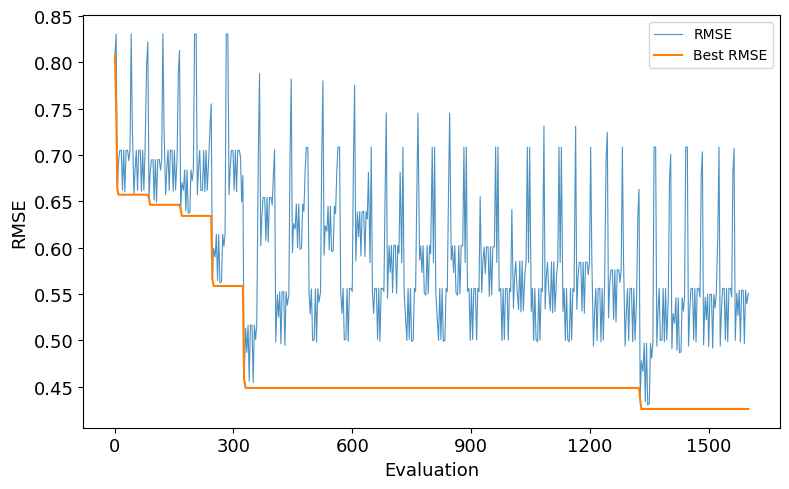

In [ ]:
from matplotlib.ticker import MaxNLocator

sample_idx = np.linspace(
    0,
    len(history_gs_V6_round1_df) - 1,
    500,
    dtype=int
)

plot_df = history_gs_V6_round1_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("Evaluation", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

## Round 2

### Halfing intervals to find value of minimum

In [ ]:
%%time

parameter_results_round2 = []

grid_rmse_history_round2 = []
grid_best_history_round2 = []

best_rmse_so_far_round2 = float("inf")


for alpha_reg1 in [1.75, 1.9, 2.0]:
    for y_reg1 in [1, 25, 40]:
        for e_reg1 in [0.001, 0.25]:
            for x_reg1 in [7.5, 9, 10]:

                for alpha_reg2 in [0.25, 0.5, 0.75]:
                    for y_reg2 in [1, 25, 40]:
                        for e_reg2 in [0.001, 0.25]:
                            for x_reg2 in [0.1, 1, 2.5]:

                                rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(
                                    alpha_reg1,
                                    y_reg1,
                                    e_reg1,
                                    x_reg1,
                                    alpha_reg2,
                                    y_reg2,
                                    e_reg2,
                                    x_reg2
                                )

                                n_pred_year2 = (p_i_year2 > 0.5).sum()

                                parameter_results_round2.append(
                                    (
                                        alpha_reg1,
                                        y_reg1,
                                        e_reg1,
                                        x_reg1,
                                        alpha_reg2,
                                        y_reg2,
                                        e_reg2,
                                        x_reg2,
                                        rmse,
                                        n_pred_year2
                                    )
                                )

                                # history
                                grid_rmse_history_round2.append(rmse)

                                best_rmse_so_far_round2 = min(
                                    best_rmse_so_far_round2,
                                    rmse
                                )

                                grid_best_history_round2.append(
                                    best_rmse_so_far_round2
                                )


parameter_results_round2_sorted = sorted(
    parameter_results_round2,
    key=lambda z: (z[8], abs(z[9] - 794))
)


print(
    "alpha_reg1, y_reg1, e_reg1, x_reg1, "
    "alpha_reg2, y_reg2, e_reg2, x_reg2, "
    "rmse, n_pred_year2"
)

for (
    alpha_reg1,
    y_reg1,
    e_reg1,
    x_reg1,
    alpha_reg2,
    y_reg2,
    e_reg2,
    x_reg2,
    rmse,
    n_pred
) in parameter_results_round2_sorted[:100]:

    print(
        f"{alpha_reg1}, "
        f"{y_reg1}, "
        f"{e_reg1}, "
        f"{x_reg1}, "
        f"{alpha_reg2}, "
        f"{y_reg2}, "
        f"{e_reg2}, "
        f"{x_reg2}, "
        f"{rmse:.4f}, "
        f"{n_pred}"
    )

alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
1.75, 1, 0.25, 9, 0.25, 40, 0.001, 0.1, 0.4054, 688
1.9, 1, 0.25, 10, 0.25, 40, 0.001, 0.1, 0.4055, 690
1.75, 1, 0.25, 9, 0.25, 25, 0.001, 0.1, 0.4055, 696
1.75, 1, 0.25, 9, 0.25, 40, 0.25, 1, 0.4055, 687
1.75, 1, 0.25, 9, 0.25, 25, 0.25, 1, 0.4056, 696
1.9, 1, 0.25, 10, 0.25, 25, 0.001, 0.1, 0.4057, 698
1.9, 1, 0.25, 10, 0.25, 40, 0.25, 1, 0.4057, 689
1.9, 1, 0.25, 10, 0.25, 25, 0.25, 1, 0.4057, 698
1.75, 1, 0.25, 9, 0.25, 1, 0.25, 0.1, 0.4064, 700
1.9, 1, 0.25, 10, 0.25, 1, 0.25, 0.1, 0.4066, 702
1.75, 1, 0.25, 9, 0.5, 25, 0.001, 2.5, 0.4067, 696
1.9, 1, 0.25, 10, 0.5, 25, 0.001, 2.5, 0.4068, 698
1.75, 1, 0.25, 9, 0.5, 1, 0.001, 0.1, 0.4072, 619
1.9, 1, 0.25, 10, 0.5, 1, 0.001, 0.1, 0.4073, 621
1.75, 1, 0.25, 9, 0.5, 1, 0.25, 2.5, 0.4075, 732
1.9, 1, 0.25, 10, 0.5, 1, 0.25, 2.5, 0.4076, 734
1.75, 1, 0.25, 9, 0.5, 40, 0.001, 2.5, 0.4077, 689
1.9, 1, 0.25, 10, 0.5, 40, 0.001, 2.5, 0.4078, 691
1.7

In [ ]:
history_gs_V6_round2_df = pd.DataFrame({
    "run": range(1, len(grid_rmse_history) + 1),
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})

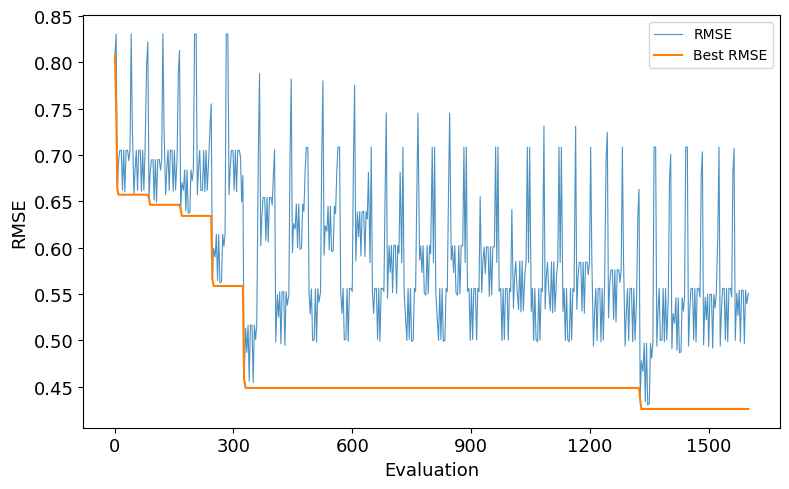

In [ ]:
from matplotlib.ticker import MaxNLocator

sample_idx = np.linspace(
    0,
    len(history_gs_V6_round2_df) - 1,
    500,
    dtype=int
)

plot_df = history_gs_V6_round2_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("Evaluation", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

## Round 3

In [ ]:
%%time

parameter_results = []

# history
grid_rmse_history = []
grid_best_history = []
best_rmse_so_far = float("inf")


for alpha_reg1 in [1.5, 1.75, 1.9]:
    for y_reg1 in [1, 10]:
        for e_reg1 in [0.25, 0.4, 0.5]:
            for x_reg1 in [8.5, 9, 9.5]:

                for alpha_reg2 in [0.1, 0.25, 0.4]:
                    for y_reg2 in [25, 40, 50]:
                        for e_reg2 in [0.001, 0.25]:
                            for x_reg2 in [0.1, 1]:

                                rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(
                                    alpha_reg1,
                                    y_reg1,
                                    e_reg1,
                                    x_reg1,
                                    alpha_reg2,
                                    y_reg2,
                                    e_reg2,
                                    x_reg2
                                )

                                n_pred_year2 = (
                                    p_i_year2 > 0.5
                                ).sum()

                                parameter_results.append(
                                    (
                                        alpha_reg1,
                                        y_reg1,
                                        e_reg1,
                                        x_reg1,
                                        alpha_reg2,
                                        y_reg2,
                                        e_reg2,
                                        x_reg2,
                                        rmse,
                                        n_pred_year2
                                    )
                                )

                                # history
                                grid_rmse_history.append(rmse)

                                best_rmse_so_far = min(
                                    best_rmse_so_far,
                                    rmse
                                )

                                grid_best_history.append(
                                    best_rmse_so_far
                                )


parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (
        z[8],
        abs(z[9] - 794)
    )
)


print(
    "alpha_reg1, y_reg1, e_reg1, x_reg1, "
    "alpha_reg2, y_reg2, e_reg2, x_reg2, "
    "rmse, n_pred_year2"
)


for (
    alpha_reg1,
    y_reg1,
    e_reg1,
    x_reg1,
    alpha_reg2,
    y_reg2,
    e_reg2,
    x_reg2,
    rmse,
    n_pred
) in parameter_results_sorted[:100]:

    print(
        f"{alpha_reg1}, "
        f"{y_reg1}, "
        f"{e_reg1}, "
        f"{x_reg1}, "
        f"{alpha_reg2}, "
        f"{y_reg2}, "
        f"{e_reg2}, "
        f"{x_reg2}, "
        f"{rmse:.4f}, "
        f"{n_pred}"
    )

alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
1.75, 1, 0.25, 9, 0.25, 50, 0.001, 0.1, 0.4051, 685
1.75, 1, 0.25, 9, 0.25, 50, 0.25, 1, 0.4053, 685
1.75, 1, 0.25, 9, 0.25, 40, 0.001, 0.1, 0.4054, 688
1.75, 1, 0.25, 9, 0.25, 25, 0.001, 0.1, 0.4055, 696
1.75, 1, 0.25, 9, 0.25, 40, 0.25, 1, 0.4055, 687
1.75, 1, 0.25, 9, 0.25, 25, 0.25, 1, 0.4056, 696
1.75, 1, 0.25, 9, 0.1, 50, 0.25, 0.1, 0.4060, 740
1.75, 1, 0.25, 9, 0.4, 50, 0.001, 1, 0.4065, 685
1.75, 1, 0.25, 9, 0.4, 40, 0.001, 1, 0.4074, 685
1.75, 1, 0.25, 9, 0.1, 40, 0.25, 0.1, 0.4078, 747
1.75, 1, 0.25, 9, 0.4, 25, 0.001, 1, 0.4089, 685
1.75, 1, 0.25, 9, 0.1, 25, 0.25, 0.1, 0.4115, 764
1.75, 1, 0.4, 9, 0.25, 50, 0.001, 0.1, 0.4129, 353
1.75, 1, 0.25, 9, 0.25, 25, 0.001, 1, 0.4129, 735
1.75, 1, 0.4, 9, 0.25, 50, 0.25, 1, 0.4130, 353
1.75, 1, 0.25, 9, 0.25, 50, 0.001, 1, 0.4131, 732
1.75, 1, 0.4, 9, 0.25, 40, 0.001, 0.1, 0.4131, 356
1.75, 1, 0.25, 9, 0.25, 40, 0.001, 1, 0.4131, 732
1.75, 1, 

In [ ]:
history_gs_v6_round3_df = pd.DataFrame({
    "run": range(1, len(grid_rmse_history) + 1),
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})

history_gs_v6_round3_df.head()

,run,rmse,best_rmse
0,1,0.550226,0.550226
1,2,0.582086,0.550226
2,3,0.527025,0.527025
3,4,0.549908,0.527025
4,5,0.546006,0.527025


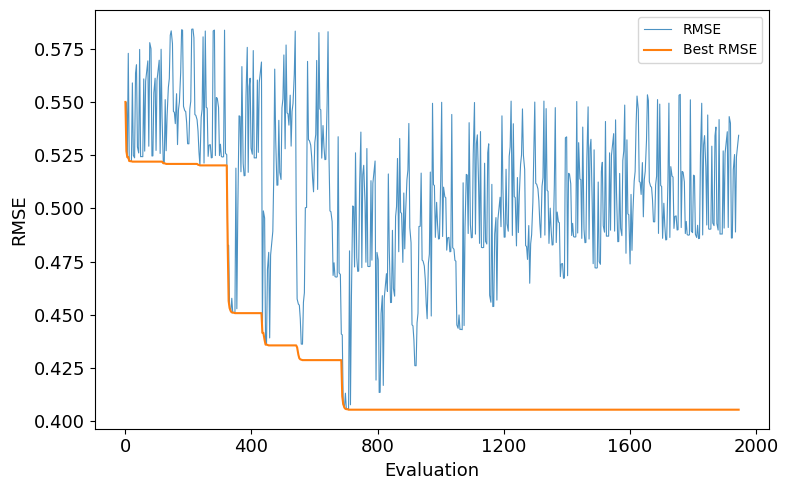

In [ ]:
from matplotlib.ticker import MaxNLocator

sample_idx = np.linspace(
    0,
    len(history_gs_v6_round3_df) - 1,
    600,
    dtype=int
)

plot_df = history_gs_v6_round3_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("Evaluation", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

# Round 4

In [ ]:
%%time

parameter_results = []

# history
grid_rmse_history = []
grid_best_history = []
best_rmse_so_far = float("inf")


for alpha_reg1 in [1.6, 1.75, 1.85]:
    for y_reg1 in [1, 2.5]:
        for e_reg1 in [0.2, 0.25, 0.3]:
            for x_reg1 in [8.5, 9, 9.5]:

                for alpha_reg2 in [0.2, 0.25, 0.3]:
                    for y_reg2 in [50, 60, 70]:
                        for e_reg2 in [0.01, 0.25]:
                            for x_reg2 in [0.1, 0.5, 1]:

                                rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(
                                    alpha_reg1,
                                    y_reg1,
                                    e_reg1,
                                    x_reg1,
                                    alpha_reg2,
                                    y_reg2,
                                    e_reg2,
                                    x_reg2
                                )

                                n_pred_year2 = (
                                    p_i_year2 > 0.5
                                ).sum()

                                parameter_results.append(
                                    (
                                        alpha_reg1,
                                        y_reg1,
                                        e_reg1,
                                        x_reg1,
                                        alpha_reg2,
                                        y_reg2,
                                        e_reg2,
                                        x_reg2,
                                        rmse,
                                        n_pred_year2
                                    )
                                )

                                # history
                                grid_rmse_history.append(rmse)

                                best_rmse_so_far = min(
                                    best_rmse_so_far,
                                    rmse
                                )

                                grid_best_history.append(
                                    best_rmse_so_far
                                )


parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (
        z[8],
        abs(z[9] - 794)
    )
)


print(
    "alpha_reg1, y_reg1, e_reg1, x_reg1, "
    "alpha_reg2, y_reg2, e_reg2, x_reg2, "
    "rmse, n_pred_year2"
)


for (
    alpha_reg1,
    y_reg1,
    e_reg1,
    x_reg1,
    alpha_reg2,
    y_reg2,
    e_reg2,
    x_reg2,
    rmse,
    n_pred
) in parameter_results_sorted[:30]:

    print(
        f"{alpha_reg1}, "
        f"{y_reg1}, "
        f"{e_reg1}, "
        f"{x_reg1}, "
        f"{alpha_reg2}, "
        f"{y_reg2}, "
        f"{e_reg2}, "
        f"{x_reg2}, "
        f"{rmse:.4f}, "
        f"{n_pred}"
    )

alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
1.75, 1, 0.2, 9, 0.2, 70, 0.01, 0.1, 0.4013, 693
1.75, 1, 0.2, 9, 0.2, 50, 0.25, 0.5, 0.4014, 691
1.75, 1, 0.2, 9, 0.2, 60, 0.01, 0.1, 0.4015, 695
1.75, 1, 0.2, 9, 0.2, 60, 0.25, 0.5, 0.4015, 689
1.75, 1, 0.2, 9, 0.2, 50, 0.01, 0.1, 0.4019, 696
1.75, 1, 0.2, 9, 0.2, 70, 0.25, 0.5, 0.4020, 659
1.75, 1, 0.25, 9, 0.2, 70, 0.01, 0.1, 0.4028, 685
1.75, 1, 0.25, 9, 0.2, 50, 0.25, 0.5, 0.4029, 683
1.75, 1, 0.25, 9, 0.2, 60, 0.01, 0.1, 0.4030, 687
1.75, 1, 0.25, 9, 0.2, 60, 0.25, 0.5, 0.4030, 681
1.75, 1, 0.2, 9, 0.25, 70, 0.01, 0.5, 0.4031, 693
1.75, 1, 0.2, 9, 0.25, 70, 0.25, 1, 0.4033, 691
1.75, 1, 0.25, 9, 0.2, 50, 0.01, 0.1, 0.4033, 688
1.75, 1, 0.2, 9, 0.25, 60, 0.01, 0.5, 0.4035, 693
1.75, 1, 0.2, 9, 0.25, 60, 0.25, 1, 0.4035, 691
1.75, 1, 0.25, 9, 0.2, 70, 0.25, 0.5, 0.4035, 651
1.75, 1, 0.2, 9, 0.25, 50, 0.01, 0.5, 0.4038, 693
1.75, 1, 0.2, 9, 0.25, 50, 0.25, 1, 0.4038, 693
1.75, 1, 0.2, 9, 0.3,

In [ ]:
history_gs_v6_round4_df = pd.DataFrame({
    "run": range(1, len(grid_rmse_history) + 1),
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})

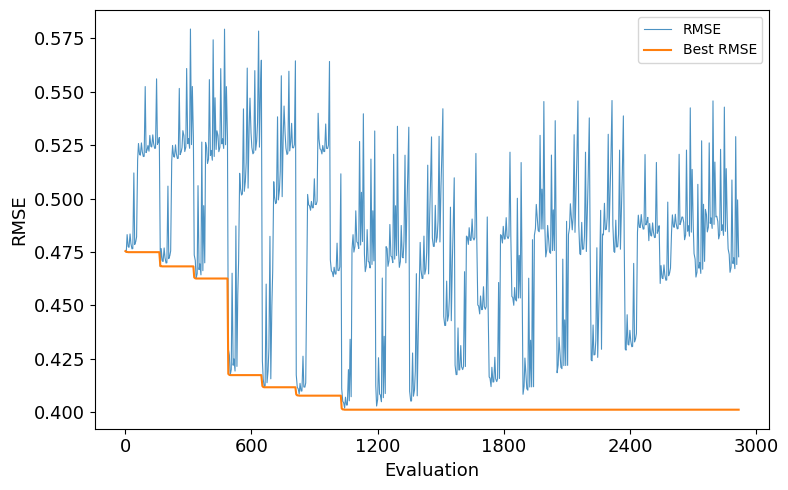

In [ ]:
from matplotlib.ticker import MaxNLocator

sample_idx = np.linspace(
    0,
    len(history_gs_v6_round4_df) - 1,
    650,
    dtype=int
)

plot_df = history_gs_v6_round4_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("Evaluation", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

# Round 5

In [ ]:
%%time

parameter_results = []

# history
grid_rmse_history = []
grid_best_history = []
best_rmse_so_far = float("inf")


for alpha_reg1 in [1.6, 1.75, 1.85]:
    for y_reg1 in [1, 1.25, 2.5]:
        for e_reg1 in [0.2, 0.25, 0.3]:
            for x_reg1 in [7, 9]:

                for alpha_reg2 in [0.1, 0.15, 0.2]:
                    for y_reg2 in [70, 80]:
                        for e_reg2 in [0.01, 0.1, 0.25]:
                            for x_reg2 in [0.1, 0.25]:

                                rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(
                                    alpha_reg1,
                                    y_reg1,
                                    e_reg1,
                                    x_reg1,
                                    alpha_reg2,
                                    y_reg2,
                                    e_reg2,
                                    x_reg2
                                )

                                n_pred_year2 = (
                                    p_i_year2 > 0.5
                                ).sum()

                                parameter_results.append(
                                    (
                                        alpha_reg1,
                                        y_reg1,
                                        e_reg1,
                                        x_reg1,
                                        alpha_reg2,
                                        y_reg2,
                                        e_reg2,
                                        x_reg2,
                                        rmse,
                                        n_pred_year2
                                    )
                                )

                                # history
                                grid_rmse_history.append(rmse)

                                best_rmse_so_far = min(
                                    best_rmse_so_far,
                                    rmse
                                )

                                grid_best_history.append(
                                    best_rmse_so_far
                                )


parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (
        z[8],
        abs(z[9] - 794)
    )
)


print(
    "alpha_reg1, y_reg1, e_reg1, x_reg1, "
    "alpha_reg2, y_reg2, e_reg2, x_reg2, "
    "rmse, n_pred_year2"
)


for (
    alpha_reg1,
    y_reg1,
    e_reg1,
    x_reg1,
    alpha_reg2,
    y_reg2,
    e_reg2,
    x_reg2,
    rmse,
    n_pred
) in parameter_results_sorted[:100]:

    print(
        f"{alpha_reg1}, "
        f"{y_reg1}, "
        f"{e_reg1}, "
        f"{x_reg1}, "
        f"{alpha_reg2}, "
        f"{y_reg2}, "
        f"{e_reg2}, "
        f"{x_reg2}, "
        f"{rmse:.4f}, "
        f"{n_pred}"
    )

alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
1.75, 1, 0.2, 9, 0.15, 70, 0.1, 0.1, 0.3995, 693
1.75, 1, 0.2, 9, 0.15, 80, 0.1, 0.1, 0.3996, 692
1.75, 1, 0.2, 9, 0.15, 70, 0.25, 0.25, 0.3996, 693
1.75, 1, 0.2, 9, 0.15, 80, 0.25, 0.25, 0.3997, 692
1.75, 1, 0.2, 9, 0.15, 80, 0.1, 0.25, 0.4001, 703
1.75, 1, 0.2, 9, 0.15, 70, 0.1, 0.25, 0.4006, 704
1.75, 1, 0.2, 9, 0.1, 80, 0.25, 0.1, 0.4008, 731
1.75, 1, 0.25, 9, 0.15, 70, 0.1, 0.1, 0.4010, 685
1.75, 1, 0.2, 9, 0.15, 70, 0.25, 0.1, 0.4010, 658
1.75, 1, 0.25, 9, 0.15, 80, 0.1, 0.1, 0.4011, 684
1.75, 1, 0.25, 9, 0.15, 70, 0.25, 0.25, 0.4011, 685
1.75, 1, 0.25, 9, 0.15, 80, 0.25, 0.25, 0.4012, 684
1.75, 1, 0.2, 9, 0.2, 80, 0.01, 0.1, 0.4012, 690
1.75, 1, 0.2, 9, 0.2, 70, 0.01, 0.1, 0.4013, 693
1.75, 1, 0.25, 9, 0.15, 80, 0.1, 0.25, 0.4016, 695
1.75, 1, 0.2, 9, 0.1, 70, 0.25, 0.1, 0.4018, 738
1.75, 1, 0.2, 9, 0.2, 80, 0.01, 0.25, 0.4019, 695
1.75, 1, 0.25, 9, 0.15, 70, 0.1, 0.25, 0.4021, 696
1.75, 1

In [ ]:
history_gs_v6_round5_df = pd.DataFrame({
    "run": range(1, len(grid_rmse_history) + 1),
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})

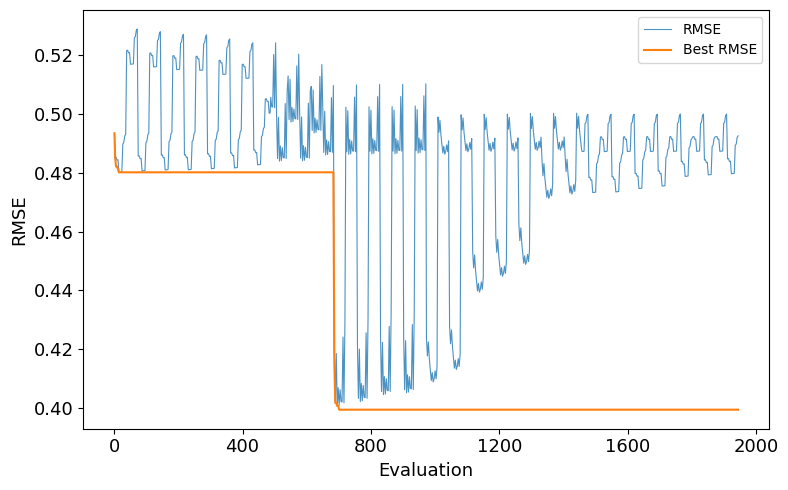

In [ ]:
from matplotlib.ticker import MaxNLocator

sample_idx = np.linspace(
    0,
    len(history_gs_v6_round5_df) - 1,
    650,
    dtype=int
)

plot_df = history_gs_v6_round5_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("Evaluation", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

# Round 6

In [ ]:
# alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
# 1.75, 1, 0.2, 9, 0.15, 70, 0.1, 0.1, 0.3995, 693
# 1.75, 1, 0.2, 9, 0.15, 80, 0.1, 0.1, 0.3996, 692
# 1.75, 1, 0.2, 9, 0.15, 70, 0.25, 0.25, 0.3996, 693
# 1.75, 1, 0.2, 9, 0.15, 80, 0.25, 0.25, 0.3997, 692
# 1.75, 1, 0.2, 9, 0.15, 80, 0.1, 0.25, 0.4001, 703
# 1.75, 1, 0.2, 9, 0.15, 70, 0.1, 0.25, 0.4006, 704
# 1.75, 1, 0.2, 9, 0.1, 80, 0.25, 0.1, 0.4008, 731
# 1.75, 1, 0.25, 9, 0.15, 70, 0.1, 0.1, 0.4010, 685
# 1.75, 1, 0.2, 9, 0.15, 70, 0.25, 0.1, 0.4010, 658
# 1.75, 1, 0.25, 9, 0.15, 80, 0.1, 0.1, 0.4011, 684
# 1.75, 1, 0.25, 9, 0.15, 70, 0.25, 0.25, 0.4011, 685
# 1.75, 1, 0.25, 9, 0.15, 80, 0.25, 0.25, 0.4012, 684

In [ ]:
%%time

parameter_results = []

# history
grid_rmse_history = []
grid_best_history = []
best_rmse_so_far = float("inf")


for alpha_reg1 in [1.6, 1.75]:
    for y_reg1 in [1, 1.1, 1.2]:
        for e_reg1 in [0.15, 0.2]:
            for x_reg1 in [7, 9]:

                for alpha_reg2 in [0.15, 0.175, 0.2]:
                    for y_reg2 in [70, 75]:
                        for e_reg2 in [0.1, 0.25]:
                            for x_reg2 in [0.1,0.15,0.2]:

                                rmse, p_i_year2, S_i_year1, C_i_year1, E_i_year1 = run_ifm_rmse(
                                    alpha_reg1,
                                    y_reg1,
                                    e_reg1,
                                    x_reg1,
                                    alpha_reg2,
                                    y_reg2,
                                    e_reg2,
                                    x_reg2
                                )

                                n_pred_year2 = (
                                    p_i_year2 > 0.5
                                ).sum()

                                parameter_results.append(
                                    (
                                        alpha_reg1,
                                        y_reg1,
                                        e_reg1,
                                        x_reg1,
                                        alpha_reg2,
                                        y_reg2,
                                        e_reg2,
                                        x_reg2,
                                        rmse,
                                        n_pred_year2
                                    )
                                )

                                # history
                                grid_rmse_history.append(rmse)

                                best_rmse_so_far = min(
                                    best_rmse_so_far,
                                    rmse
                                )

                                grid_best_history.append(
                                    best_rmse_so_far
                                )


parameter_results_sorted = sorted(
    parameter_results,
    key=lambda z: (
        z[8],
        abs(z[9] - 794)
    )
)


print(
    "alpha_reg1, y_reg1, e_reg1, x_reg1, "
    "alpha_reg2, y_reg2, e_reg2, x_reg2, "
    "rmse, n_pred_year2"
)


for (
    alpha_reg1,
    y_reg1,
    e_reg1,
    x_reg1,
    alpha_reg2,
    y_reg2,
    e_reg2,
    x_reg2,
    rmse,
    n_pred
) in parameter_results_sorted[:100]:

    print(
        f"{alpha_reg1}, "
        f"{y_reg1}, "
        f"{e_reg1}, "
        f"{x_reg1}, "
        f"{alpha_reg2}, "
        f"{y_reg2}, "
        f"{e_reg2}, "
        f"{x_reg2}, "
        f"{rmse:.4f}, "
        f"{n_pred}"
    )

alpha_reg1, y_reg1, e_reg1, x_reg1, alpha_reg2, y_reg2, e_reg2, x_reg2, rmse, n_pred_year2
1.75, 1.1, 0.15, 9, 0.15, 70, 0.1, 0.1, 0.3993, 695
1.75, 1.1, 0.15, 9, 0.15, 75, 0.1, 0.1, 0.3994, 694
1.75, 1.1, 0.15, 9, 0.15, 75, 0.1, 0.15, 0.3994, 697
1.75, 1, 0.2, 9, 0.15, 70, 0.1, 0.1, 0.3995, 693
1.75, 1, 0.2, 9, 0.15, 75, 0.1, 0.1, 0.3995, 692
1.75, 1.1, 0.15, 9, 0.15, 70, 0.25, 0.2, 0.3995, 694
1.75, 1.1, 0.15, 9, 0.15, 70, 0.1, 0.15, 0.3995, 699
1.75, 1, 0.2, 9, 0.15, 75, 0.1, 0.15, 0.3996, 695
1.75, 1, 0.2, 9, 0.15, 70, 0.25, 0.2, 0.3997, 692
1.75, 1, 0.2, 9, 0.15, 70, 0.1, 0.15, 0.3997, 697
1.75, 1.1, 0.15, 9, 0.15, 75, 0.25, 0.2, 0.3997, 683
1.75, 1.1, 0.15, 9, 0.15, 75, 0.1, 0.2, 0.3997, 700
1.75, 1.2, 0.15, 9, 0.15, 70, 0.1, 0.1, 0.3998, 690
1.75, 1.2, 0.15, 9, 0.15, 75, 0.1, 0.1, 0.3998, 689
1.75, 1, 0.2, 9, 0.15, 75, 0.25, 0.2, 0.3999, 681
1.75, 1, 0.2, 9, 0.15, 75, 0.1, 0.2, 0.3999, 698
1.75, 1.2, 0.15, 9, 0.15, 75, 0.1, 0.15, 0.3999, 692
1.75, 1.1, 0.15, 9, 0.15, 70, 0.1, 0.

In [ ]:
history_gs_v6_round6_df = pd.DataFrame({
    "run": range(1, len(grid_rmse_history) + 1),
    "rmse": grid_rmse_history,
    "best_rmse": grid_best_history
})

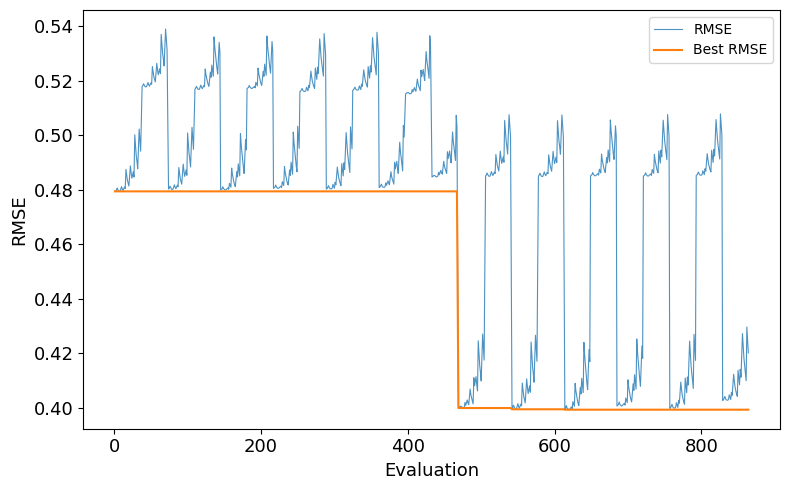

In [ ]:
from matplotlib.ticker import MaxNLocator

sample_idx = np.linspace(
    0,
    len(history_gs_v6_round6_df) - 1,
    650,
    dtype=int
)

plot_df = history_gs_v6_round6_df.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df.index + 1,
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df.index + 1,
    plot_df["best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("Evaluation", fontsize = 13)
plt.ylabel("RMSE", fontsize = 13)
plt.tick_params(labelsize=13)

plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
%whos

Variable                          Type         Data/Info
--------------------------------------------------------
A_j                               ndarray      2567: 2567 elems, type `float64`, 20536 bytes
C_i_year1                         ndarray      2567: 2567 elems, type `float64`, 20536 bytes
D_ij                              ndarray      2567x2567: 6589489 elems, type `float64`, 52715912 bytes (50.27381134033203 Mb)
E_i_year1                         ndarray      2567: 2567 elems, type `float64`, 20536 bytes
MaxNLocator                       type         <class 'matplotlib.ticker.MaxNLocator'>
O_j                               ndarray      2567: 2567 elems, type `float64`, 20536 bytes
S_i_year1                         ndarray      2567: 2567 elems, type `float64`, 20536 bytes
alpha_reg1                        float        1.75
alpha_reg2                        float        0.175
best_rmse_so_far                  float64      0.3993406169889091
best_rmse_so_far_round2           fl

In [ ]:
history_gs_v6_all = pd.concat(
    [
        history_gs_V6_round1_df.assign(round="Round 1"),
        history_gs_V6_round2_df.assign(round="Round 2"),
        history_gs_v6_round3_df.assign(round="Round 3"),
        history_gs_v6_round4_df.assign(round="Round 4"),
        history_gs_v6_round5_df.assign(round="Round 5"),
        history_gs_v6_round6_df.assign(round="Round 6")
    ],
    ignore_index=True
)

# continuous global run number
history_gs_v6_all.insert(
    0,
    "global_run",
    range(1, len(history_gs_v6_all) + 1)
)

# global best RMSE across all rounds
history_gs_v6_all["global_best_rmse"] = (
    history_gs_v6_all["rmse"].cummin()
)

print(history_gs_v6_all.shape)
history_gs_v6_all.head()

(12184, 6)


,global_run,run,rmse,best_rmse,round,global_best_rmse
0,1,1,0.807774,0.807774,Round 1,0.807774
1,2,2,0.830760,0.807774,Round 1,0.807774
2,3,3,0.751922,0.751922,Round 1,0.751922
3,4,4,0.830760,0.751922,Round 1,0.751922
4,5,5,0.727438,0.727438,Round 1,0.727438


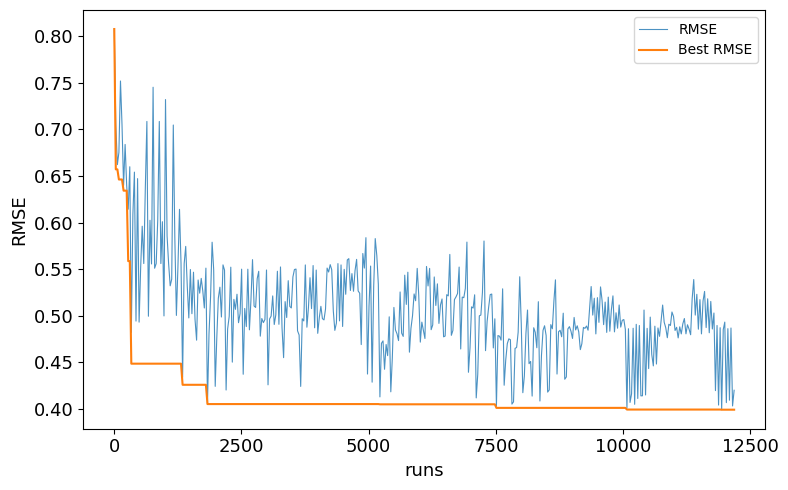

In [ ]:
# plot all rounds

sample_idx = np.linspace(
    0,
    len(history_gs_v6_all) - 1,
    400,
    dtype=int
)

plot_df = history_gs_v6_all.iloc[sample_idx]

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["global_run"],
    plot_df["rmse"],
    linewidth=0.8,
    alpha=0.8,
    label="RMSE"
)

plt.plot(
    plot_df["global_run"],
    plot_df["global_best_rmse"],
    linewidth=1.5,
    label="Best RMSE"
)

plt.xlabel("runs", fontsize=13)
plt.ylabel("RMSE", fontsize=13)

plt.tick_params(labelsize=13)
plt.gca().xaxis.set_major_locator(MaxNLocator(6))

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
history_gs_v6_all.to_csv(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_grid_search_V6_all_history.csv", index=False)



---

